Para este flow de Farneback, hemos usado de fuente la documentación oficial de opencv, https://docs.opencv.org/4.x/d4/dee/tutorial_optical_flow.html hemos seguido los paso que se nos explica la documentación.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

(-0.5, 1279.5, 719.5, -0.5)

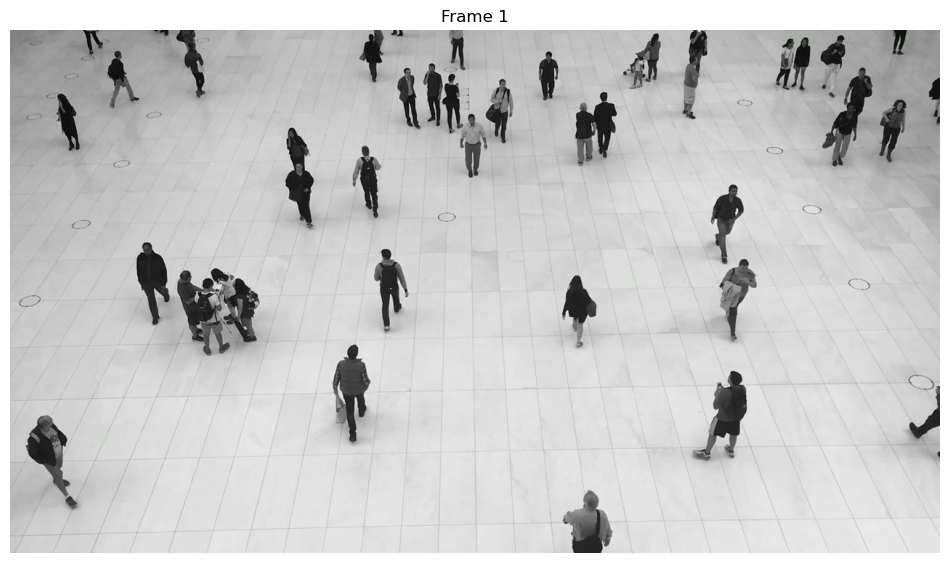

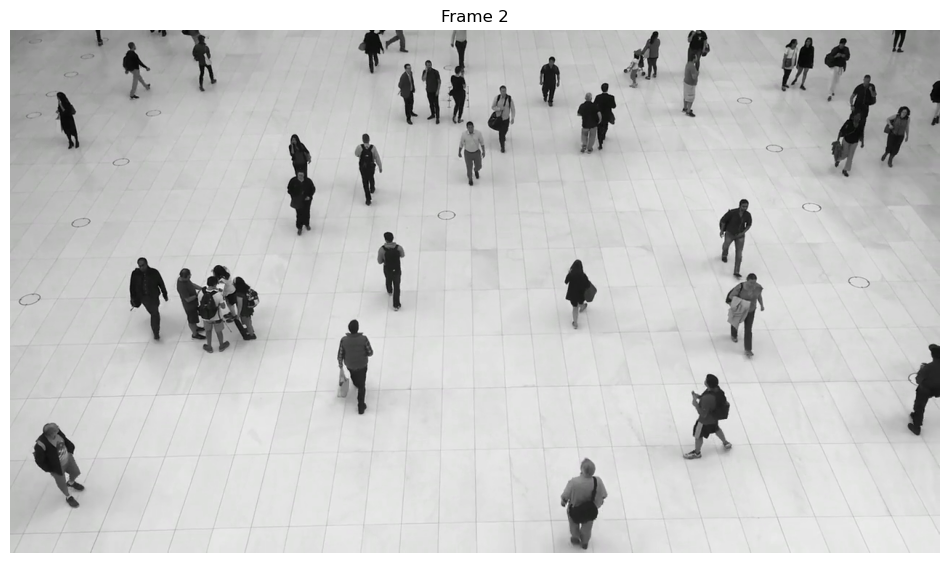

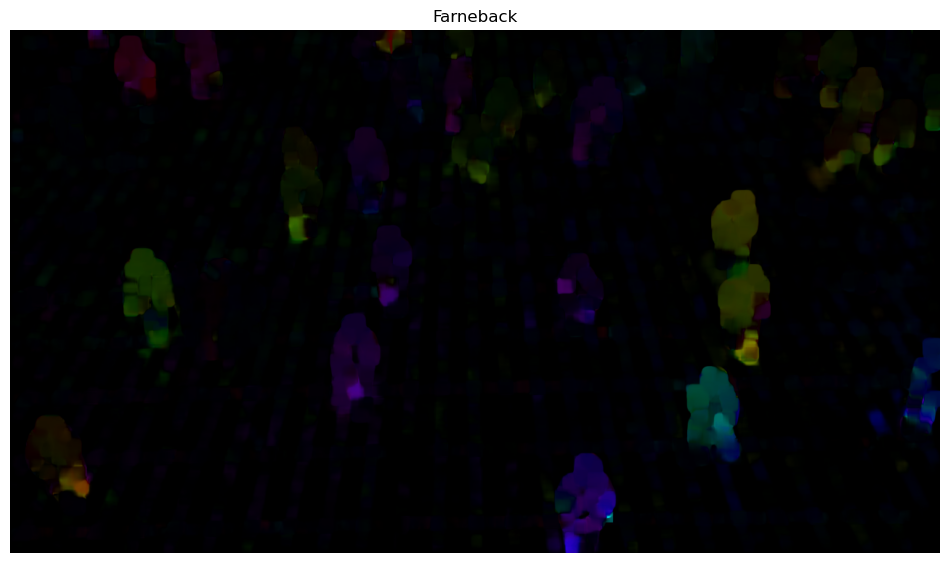

In [2]:
ruta_video = "Videos/people2.mp4"  

cap = cv.VideoCapture(ruta_video)

ret1, frame1 = cap.read()
gray1 = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)

hsv = np.zeros_like(frame1)
hsv[..., 1] = 255

while True:
    ret, frame2 = cap.read()
    
    if not ret:
        print('No frames grabbed!')
        break
    
    gray2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)
    
    farneback = cv.calcOpticalFlowFarneback(gray1, gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    
    mag, ang = cv.cartToPolar(farneback[..., 0], farneback[..., 1])
    
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv.normalize(mag, None, 0, 255, cv.NORM_MINMAX)
    
    color = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)
    
    cv.imshow('Farneback Flow', color)

    k = cv.waitKey(30) & 0xff
    if k == 27:
        break
    
    gray1 = gray2

cap.release()
cv.destroyAllWindows()

# Mostrar con matplotlib
plt.figure(figsize=(12,8))
plt.imshow(cv.cvtColor(frame1, cv.COLOR_BGR2RGB))
plt.title("Frame 1")
plt.axis('off')

plt.figure(figsize=(12,8))
plt.imshow(cv.cvtColor(frame2, cv.COLOR_BGR2RGB))
plt.title("Frame 2")
plt.axis('off')

plt.figure(figsize=(12,8))
plt.imshow(cv.cvtColor(color, cv.COLOR_BGR2RGB))
plt.title("Farneback")
plt.axis('off')
